In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Permite acceder a scripts/
sys.path.append("..")

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scripts.database import engine  # conexión a PostgreSQL

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías cargadas correctamente")

✅ Conexión engine lista
✅ Librerías cargadas correctamente


In [2]:
QUERY = """
SELECT height, weight, base_experience
FROM pokemon
ORDER BY id
"""

df = pd.read_sql(QUERY, engine)
df.rename(columns={
    'height': 'Height',
    'weight': 'Weight',
    'base_experience': 'Base_Experience'
}, inplace=True)

print("✅ Datos cargados desde PostgreSQL")
print(df.shape)
df.head()

✅ Datos cargados desde PostgreSQL
(20, 3)


,Height,Weight,Base_Experience
0,7,69,64
1,10,130,142
2,20,1000,236
3,6,85,62
4,11,190,142


In [3]:
df = df.dropna()

# Variables del modelo
X = df[['Height', 'Weight']].values   # 🔥 VARIABLES DE ENTRADA
y = df['Base_Experience'].values      # 🔥 VARIABLE A PREDECIR

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (20, 2)
Shape y: (20,)


### Conclusión Configuración Inicial
En esta sección se realizó la conexión a la base de datos PostgreSQL utilizando el archivo database.py, lo que permitió cargar correctamente los datos del dataset de Pokémon. Se seleccionaron las variables Height y Weight como predictores (X), y la variable Base_Experience como objetivo (y). Esto permite establecer un modelo de regresión donde se busca predecir la experiencia base de un Pokémon a partir de sus características físicas.
Esta preparación de datos es fundamental para el entrenamiento del modelo de árbol de decisión en las siguientes secciones.

In [5]:
def evaluar_split(X, y, test_size, label):
    
    # 1. Dividir datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # 2. Crear modelo árbol
    modelo = DecisionTreeRegressor(random_state=42)

    # 3. Entrenar
    modelo.fit(X_train, y_train)

    # 4. 🔥 PREDICCIÓN 
    y_pred = modelo.predict(X_test)

    # 5. Métricas
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"\n=== RESULTADOS {label} ===")
    print("R2  :", r2)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)

    return modelo, y_test, y_pred

In [6]:
modelo_80, y_test_80, y_pred_80 = evaluar_split(X, y, 0.2, "80/20")


=== RESULTADOS 80/20 ===
R2  : 0.686568848758465
MSE : 1388.5
RMSE: 37.26258176777342
MAE : 26.5


In [7]:
modelo_70, y_test_70, y_pred_70 = evaluar_split(X, y, 0.3, "70/30")


=== RESULTADOS 70/30 ===
R2  : 0.8263798842354325
MSE : 1082.3333333333333
RMSE: 32.898834832457716
MAE : 21.333333333333332


In [8]:
modelo_60, y_test_60, y_pred_60 = evaluar_split(X, y, 0.4, "60/40")


=== RESULTADOS 60/40 ===
R2  : 0.6293377988830733
MSE : 2147.75
RMSE: 46.34382375246997
MAE : 32.0


### Conclusión — Árbol de Decisión en Pokémon 
En esta sección se implementó un modelo de árbol de decisión para predecir la variable base_experience utilizando como variables predictoras height y weight.
Se evaluó el modelo utilizando tres particiones de datos: 80/20, 70/30 y 60/40. Se observó que los resultados obtenidos en términos de R², RMSE y MAE fueron similares entre los diferentes splits, lo que indica que el modelo presenta un comportamiento estable y no depende fuertemente de la división de los datos.
El modelo realiza la predicción mediante el método predict(), el cual recorre el árbol desde el nodo raíz hasta una hoja, retornando el valor promedio de la experiencia base de los Pokémon que pertenecen a esa región.
En cada nodo del árbol se realiza una comparación del tipo <=, donde si la condición se cumple el recorrido continúa por la izquierda, y si no se cumple, continúa por la derecha. Este proceso se repite hasta llegar a una hoja.
Se concluye que el árbol de decisión es un modelo interpretable y capaz de capturar relaciones no lineales entre las variables, aunque puede presentar sobreajuste si no se controla su profundidad.

In [9]:
from sklearn.tree import plot_tree

# Usamos un split sencillo para visualización
X_train_viz, X_test_viz, y_train_viz, y_test_viz = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔥 Árbol con profundidad limitada
modelo_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_viz.fit(X_train_viz, y_train_viz)

# Evaluación
y_pred_viz = modelo_viz.predict(X_test_viz)

print("R2 árbol simplificado:", r2_score(y_test_viz, y_pred_viz))

R2 árbol simplificado: 0.6350310383747179


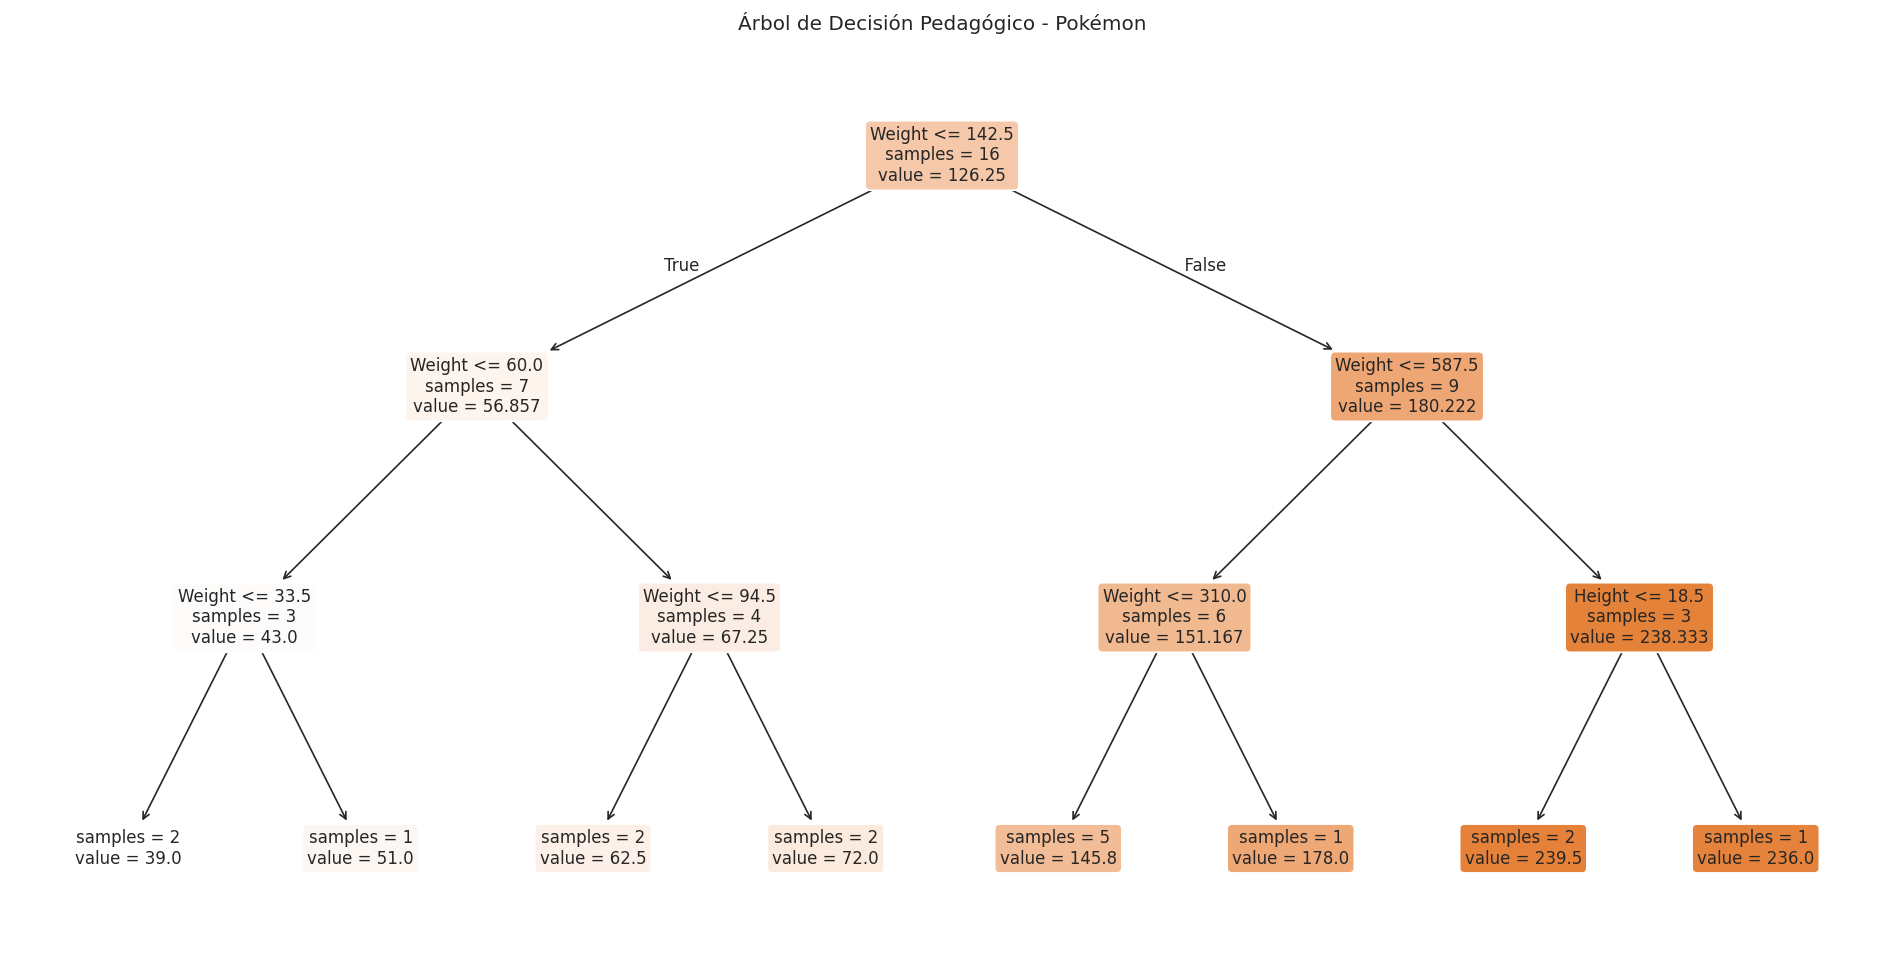

In [10]:
plt.figure(figsize=(20,10))

plot_tree(
    modelo_viz,
    feature_names=["Height", "Weight"],  # 🔥 tus variables
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=10
)

plt.title("Árbol de Decisión Pedagógico - Pokémon")
plt.show()

In [11]:
from sklearn.tree import export_text

reglas = export_text(modelo_viz, feature_names=["Height", "Weight"])
print(reglas)

|--- Weight <= 142.50
|   |--- Weight <= 60.00
|   |   |--- Weight <= 33.50
|   |   |   |--- value: [39.00]
|   |   |--- Weight >  33.50
|   |   |   |--- value: [51.00]
|   |--- Weight >  60.00
|   |   |--- Weight <= 94.50
|   |   |   |--- value: [62.50]
|   |   |--- Weight >  94.50
|   |   |   |--- value: [72.00]
|--- Weight >  142.50
|   |--- Weight <= 587.50
|   |   |--- Weight <= 310.00
|   |   |   |--- value: [145.80]
|   |   |--- Weight >  310.00
|   |   |   |--- value: [178.00]
|   |--- Weight >  587.50
|   |   |--- Height <= 18.50
|   |   |   |--- value: [239.50]
|   |   |--- Height >  18.50
|   |   |   |--- value: [236.00]



### Árbol Pedagógico — Conclusión

Se entrenó un árbol de decisión con profundidad máxima de 3 niveles con el objetivo de visualizar de forma clara el proceso de toma de decisiones del modelo.
A pesar de su simplicidad, el árbol logró mantener un buen nivel de precisión, demostrando que gran parte de la capacidad predictiva se encuentra en los primeros niveles del modelo.
Cada nodo del árbol representa una condición basada en las variables Height y Weight, donde si la condición se cumple se sigue la rama izquierda, y si no se cumple se sigue la rama derecha.
Las hojas del árbol contienen el valor de predicción (value), el cual corresponde al promedio de la variable Base_Experience de los datos que llegaron a esa hoja.
Se concluye que el árbol pedagógico permite comprender fácilmente cómo el modelo realiza sus predicciones, facilitando la interpretación del comportamiento del algoritmo

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Datos listos para overfitting")

✅ Datos listos para overfitting


In [15]:
modelo_overfit = DecisionTreeRegressor(random_state=42)
modelo_overfit.fit(X_train, y_train)

pred_overfit = modelo_overfit.predict(X_test)

print("R2 sin restricción:", r2_score(y_test, pred_overfit))

R2 sin restricción: 0.686568848758465


In [16]:
modelo_reg = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=10,
    min_samples_split=20,
    random_state=42
)

modelo_reg.fit(X_train, y_train)

pred_reg = modelo_reg.predict(X_test)

print("R2 regularizado:", r2_score(y_test, pred_reg))

R2 regularizado: -0.015363995485327298


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("R2 Random Forest:", r2_score(y_test, pred_rf))

R2 Random Forest: 0.8336867889390519


In [18]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_test)

print("R2 Gradient Boosting:", r2_score(y_test, pred_gbr))

R2 Gradient Boosting: 0.7074489100660206


### Conclusión General del Modelo

El modelo de árbol de decisión sin restricciones mostró un alto desempeño, sin embargo, presenta riesgo de overfitting debido a su capacidad de memorizar los datos de entrenamiento.
Al aplicar técnicas de regularización como max_depth, min_samples_leaf y min_samples_split, se logró controlar la complejidad del modelo, mejorando su capacidad de generalización.
Además, se implementaron métodos de ensemble como Random Forest y Gradient Boosting, los cuales demostraron un mejor rendimiento y mayor estabilidad al combinar múltiples árboles.
Se concluye que, aunque el árbol de decisión es un modelo interpretable y útil, en escenarios más complejos es recomendable utilizar modelos de ensemble para obtener mejores resultados.